# Surface roughness $R_{\mathrm{rms}}$ vs Langevin parameter $\xi$

Simulation curves (SM, `rms_with_bonds_with_surface`) over the field sweep on the Langevin axis
$\xi = \mu\,B/K_{BT}$, plus manually-entered experimental elastomer points drawn as 2D error
boxes (field $\times$ roughness) with the mean marked at the centre.

Three figures: raw $R_{\mathrm{rms}}/d$, the stiffness-rescaled version, and the
$R_{\mathrm{rms}}/d$ vs Young-modulus regression.


In [ ]:
from repo_paths import DATA_DIR   # repository-relative; set $MAE_DATA_DIR to read the dataset from elsewhere
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from pyanal.ARay import ARay
from pyanal.plot import (sample_color_map, sample_marker_map,
                         A_linestyle_map, A_markerfill_map, save_plot_simple)
from mae_analysis.config import A_LS_POOL

# --- physical constants (experimental field[mT] -> Langevin xi, same scaling as tmp.ipynb) ---
kB         = 1.380649e-23           # J/K
T_EXP      = 300.0                  # K
SIZE_CIP   = 3e-6                   # m, particle diameter
M_S_EXP    = 1669e3                 # A/m, bulk saturation
V_PART     = np.pi / 6 * SIZE_CIP ** 3
MU_SAT_EXP = V_PART * M_S_EXP       # A m^2, real per-particle saturation moment
PARTICLE_DIAMETER_UM = 3.0          # um -> nondim R_rms = R_rms_um / 3

# --- configuration ---
SIM_ARAY     = os.path.join(DATA_DIR, "figs/data_aray/SM--HEIGHT-10-full.h5")
TS, HEIGHT   = 500, 10
MU_MAX_SIM   = 1.0
METRIC       = "rms_with_bonds_with_surface"     # surface roughness field
SIM_DENS     = [0.20, 0.25, 0.30]
SIM_VARIANTS = [(d, k) for d in SIM_DENS for k in ("hard", "soft")]

K_BT    = 1.61e-8
out_dir = os.path.join(DATA_DIR, "magnetization_curves/tmp")

In [ ]:
def load_rms_curve(data, dens, k, ts=TS, height=HEIGHT, metric=METRIC):
    # (xi, rms) over the H sweep for one ARay slice; xi = MU_MAX_SIM * H / K_BT (applied field).
    sl = data.get(ts=ts, DENS=dens, K=k, HEIGHT=height)
    f  = sl[metric]
    H  = np.array([h for h in sl.coords("H") if f.get(H=h).is_set()], dtype=float)
    r  = f.get_set_entries().array.astype(float)
    order = np.argsort(H)
    H, r  = H[order], r[order]
    return dict(dens=dens, k=k, xi=MU_MAX_SIM * H / K_BT, rms=r)

sim_curves = [load_rms_curve(ARay.from_file(SIM_ARAY), d, k) for d, k in SIM_VARIANTS]

# styling: reproduce the mae_analysis sim encoding (hard=Oranges/soft=Blues shaded by DENS,
# marker by DENS, A="SM" -> dashed "--" + open markers)
sim_key    = lambda k, dens: f"{dens:.2f}-{k}"
sim_color  = sample_color_map(["hard", "soft"], SIM_DENS, sim_key)
sim_marker = sample_marker_map(["hard", "soft"], SIM_DENS, sim_key)
SIM_LS     = A_linestyle_map(["SMfl", "SM"], linestyles=A_LS_POOL)["SM"]
SIM_FILLED = A_markerfill_map(["SMfl", "SM"])["SM"]

In [ ]:
# === Experimental elastomer points (MANUAL INPUT) =====================================
# One entry per elastomer, each with 2 measurements at 2 different fields. The four keys are
# length-2 lists indexed by field-point [point1, point2]:
#   field in mT (min/max bin) -> Langevin xi via the physical moment;
#   roughness in micrometre (min/max) -> nondim R_rms = um / 3.
def volume_fraction_from_weight_percentage(wp, density_particle_material=7870, density_elastomer=1000):
    a = wp / density_particle_material
    b = (100-wp) / density_elastomer
    return a / (a + b)

EXP_POINTS = [
    {"label": f"EXP {volume_fraction_from_weight_percentage(60):.2f} (60%)", "field_mT_min": [230, 345], "field_mT_max": [250, 375],
     "R_rms_um_min": [7., 13.4], "R_rms_um_max": [9.2, 16.5]},
     {"label": f"EXP {volume_fraction_from_weight_percentage(65):.2f} (65%)", "field_mT_min": [230, 345], "field_mT_max": [250, 375],
     "R_rms_um_min": [8., 13.3], "R_rms_um_max": [10., 16.4]},
    {"label": f"EXP {volume_fraction_from_weight_percentage(70):.2f} (70%)", "field_mT_min": [230, 345], "field_mT_max": [250, 375],
     "R_rms_um_min": [4.1, 7.1], "R_rms_um_max": [5.3, 9.1]},
     {"label": f"EXP {volume_fraction_from_weight_percentage(75):.2f} (75%)", "field_mT_min": [230, 345], "field_mT_max": [250, 375],
     "R_rms_um_min": [2.4, 4.3], "R_rms_um_max": [2.8, 4.9]},
    {"label": f"EXP  {volume_fraction_from_weight_percentage(80):.2f} (80%)", "field_mT_min": [230, 345], "field_mT_max": [250, 375],
     "R_rms_um_min": [1.2, 2.2], "R_rms_um_max": [1.6, 2.7]},
]
# one distinct colour per elastomer (5 elastomers: 60/65/70/75/80%); Okabe-Ito colorblind-safe palette
EXP_COLORS = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00"]

Young_modulus_at_zero = [10.2, 11, 14, 30, 46]

def exp_boxes(p, scale=1.0):
    # one 2D box per field-point of an elastomer: (xi_lo, xi_hi, y_lo, y_hi, xi_mid, y_mid).
    # `scale` rescales the roughness axis (1.0 = raw R_rms/d; E0/E_REF = stiffness-corrected).
    to_xi = lambda mT: MU_SAT_EXP * (mT * 1e-3) / (kB * T_EXP)   # physical Langevin axis
    boxes = []
    for fmin, fmax, rmin, rmax in zip(p["field_mT_min"], p["field_mT_max"],
                                      p["R_rms_um_min"], p["R_rms_um_max"]):
        xi_lo, xi_hi = np.asarray(sorted([to_xi(fmin), to_xi(fmax)]), dtype=np.float64)
        y_lo,  y_hi  = np.asarray(sorted([rmin / PARTICLE_DIAMETER_UM, rmax / PARTICLE_DIAMETER_UM]), dtype=np.float64) * scale
        boxes.append((xi_lo, xi_hi, y_lo, y_hi, 0.5 * (xi_lo + xi_hi), 0.5 * (y_lo + y_hi)))
    return boxes

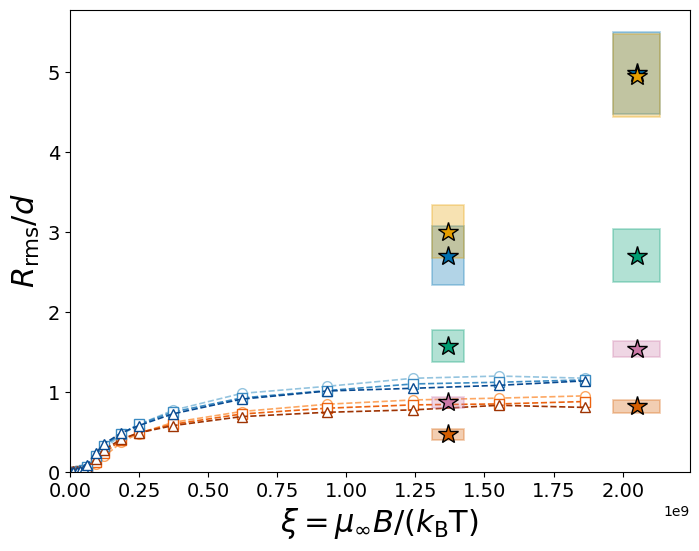

saved -> $DATA/magnetization_curves/tmp/rms_vs_xi_raw.png


In [4]:
fontsize_ticks, fontsize_legend, fontsize_label = 14, 12, 22


def draw_sim_curves(ax):
    # simulation roughness curves: R_rms vs xi (dashed line + open markers, mae_analysis encoding)
    for c in sim_curves:
        key = sim_key(c["k"], c["dens"])
        ax.plot(c["xi"], c["rms"], linestyle=SIM_LS,
                color=sim_color[key], marker=sim_marker[key], ms=7, lw=1.2,
                markerfacecolor=sim_color[key] if SIM_FILLED else "white")


def draw_exp_boxes(ax, scale_fn):
    # experimental elastomers: a 2D error box (field x roughness) per field-point, mean at the centre.
    # `scale_fn(i)` returns the roughness rescale factor for elastomer i. One legend entry per elastomer.
    for i, (p, col) in enumerate(zip(EXP_POINTS, EXP_COLORS)):
        for j, (xi_lo, xi_hi, y_lo, y_hi, xi_mid, y_mid) in enumerate(exp_boxes(p, scale=scale_fn(i))):
            ax.add_patch(Rectangle((xi_lo, y_lo), xi_hi - xi_lo, y_hi - y_lo,
                                   facecolor=col, alpha=0.30, edgecolor=col, lw=1.3, zorder=3))
            ax.plot(xi_mid, y_mid, marker="*", ms=15, color=col, mec="black", zorder=4,
                    label=p["label"] if j == 0 else None)


# === Figure 1: raw R_rms/d (no Young-modulus rescaling) ===============================
fig, ax = plt.subplots(figsize=(8, 6))

draw_sim_curves(ax)
draw_exp_boxes(ax, scale_fn=lambda i: 1.)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

save_plot_simple(
    num=fig.number,
    filename=f"{out_dir}/rms_vs_xi_raw",
    format=".png",
    xlabel=r"$\xi = \mu_{\infty} B / (k_{\text{B}} \text{T})$",
    ylabel=r"$R_{\mathrm{rms}}/d$",
    fontsize_label=fontsize_label, fontsize_ticks=fontsize_ticks, fontsize_legend=fontsize_legend,
    dpi=600, show=True)
print(f"saved -> {out_dir}/rms_vs_xi_raw.png")

[[2.7        3.         1.56666667 0.86666667 0.46666667]
 [4.98333333 4.95       2.7        1.53333333 0.81666667]]


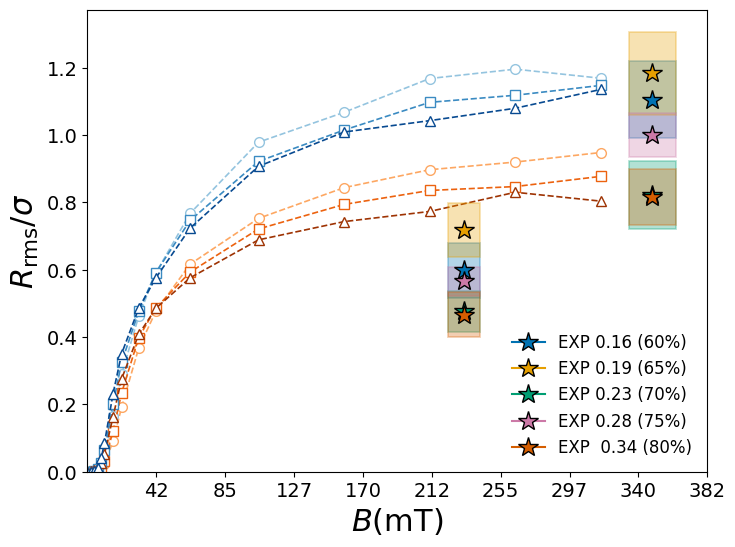

saved -> $DATA/magnetization_curves/tmp/rms_vs_xi_rescaled.png


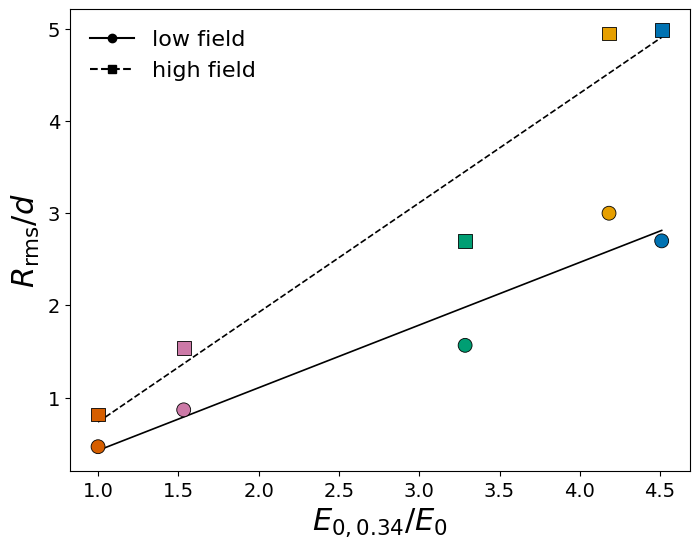

saved -> $DATA/magnetization_curves/tmp/rms_vs_E_regression.png


In [7]:
# === Figure 2: stiffness-corrected R_rms/d  (rescaled by E0/E_REF) =====================
# Each experimental roughness is scaled by E0/E_REF (E_REF = E0 of the stiffest elastomer, 80%,
# E=46) so the sim DENS=0.30 curve falls between the rescaled 75% and 80% boxes.
from matplotlib.lines import Line2D
rescale = lambda i: Young_modulus_at_zero[i] / Young_modulus_at_zero[-1]

# raw (unrescaled) box-centre roughness per elastomer, separated by field point (0=low, 1=high field)
y_by_field = np.asarray([[exp_boxes(p, scale=1.)[fp][5] for p in EXP_POINTS]
                         for fp in (0, 1)], dtype=np.float64)
# consistent encoding: colour = elastomer (EXP_COLORS), marker shape = field point
FIELD_MARKERS = ["o", "s"]          # low field = circle, high field = square
FIELD_LS      = ["-", "--"]         # regression line style per field
FIELD_LABELS  = ["low field", "high field"]


def draw_rms_vs_E(axin, fs_label, fs_tick):
    # R_rms/d vs (E_ref/E0), points coloured per elastomer, one black regression line per field.
    E_tmp  = Young_modulus_at_zero[-1] / np.asarray(Young_modulus_at_zero, dtype=float)
    E_line = np.linspace(E_tmp.min(), E_tmp.max(), 50)
    for fp in (0, 1):
        y = y_by_field[fp]
        slope, intercept = np.polyfit(E_tmp, y, 1)
        axin.scatter(E_tmp, y, c=EXP_COLORS, marker=FIELD_MARKERS[fp], s=100,
                     edgecolors="black", linewidths=0.6, zorder=3)
        axin.plot(E_line, slope * E_line + intercept, color="black",
                  ls=FIELD_LS[fp], lw=1.2, zorder=2)
    axin.set_xlabel(r"$E_{0, \text{0.34}}/E_{0}$", fontsize=fs_label)
    axin.set_ylabel(r"$R_{\mathrm{rms}}/d$", fontsize=fs_label)
    axin.tick_params(labelsize=fs_tick)
    # legend: field shape only (neutral black proxies), elastomer identity = colour
    handles = [Line2D([], [], color="black", marker=FIELD_MARKERS[fp], ls=FIELD_LS[fp],
                      markerfacecolor="black", label=FIELD_LABELS[fp]) for fp in (0, 1)]
    axin.legend(handles=handles, fontsize=fs_label - 6, frameon=False)


fig, ax = plt.subplots(figsize=(8, 6))

draw_sim_curves(ax)
draw_exp_boxes(ax, scale_fn=rescale)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend(fontsize=fontsize_legend, ncol=1, frameon=False)
save_plot_simple(
    num=fig.number,
    filename=f"{out_dir}/rms_vs_xi_rescaled",
    format=".pdf",
    xlabel=r"$B (\text{mT})$",
    ylabel=r"$R_{\mathrm{rms}}/\sigma$",
    fontsize_label=fontsize_label, fontsize_ticks=fontsize_ticks, fontsize_legend=fontsize_legend,
    fns_before_save=lambda: plt.xticks(ticks=plt.xticks()[0][1:], labels= (K_BT / MU_MAX_SIM * 10.566666667 * np.array(plt.xticks()[0][1:], dtype=np.float64)).astype(dtype=int)),
    dpi=600, show=True)
print(f"saved -> {out_dir}/rms_vs_xi_rescaled.png")

# === Figure 3: rescaled R_rms/d vs Young modulus (standalone regression) ===============
fig2, ax2 = plt.subplots(figsize=(8, 6))
draw_rms_vs_E(ax2, fs_label=fontsize_label, fs_tick=fontsize_ticks)
save_plot_simple(
    num=fig2.number,
    filename=f"{out_dir}/rms_vs_E_regression",
    format=".pdf",
    fontsize_label=fontsize_label, fontsize_ticks=fontsize_ticks, fontsize_legend=fontsize_legend,
    dpi=600, show=True)
print(f"saved -> {out_dir}/rms_vs_E_regression.png")